# train $f_{\rm surv}$ emulator

In [1]:
import os
import numpy as np

In [2]:
import copy
import torch
import torch.nn as nn 
import torch.utils.data
import torch.optim as optim
import torch.nn.functional as F 

In [3]:
import util as U
from sedflow import flows

/global/homes/c/chahah/.conda/envs/gqp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# --- plotting --- 
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [5]:
cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if cuda else "cpu")

## load training and test data 

In [6]:
dat_dir = os.path.join(U.data_dir(), 'seds', 'modelb') 

i = 0 
sps      = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_sps.npz' % i))['arr_0'][:,1:9]
sps[:,6] = np.log10(sps[:,6])
sps[:,7] = np.log10(sps[:,7])
#sps     = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_unt.npz' % i))['arr_0'][:,1:8]
#sps[:,5] = np.log10(sps[:,5])
#sps[:,6] = np.log10(sps[:,6])
tage    = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_t_age.npz.npy' % i))
msurv_nmf   = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_nmf.npz.npy' % i))
msurv_burst = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_burst.npz.npy' % i))

thetas = np.concatenate([sps, tage[:,None]], axis=1)

In [7]:
# load valid data
i = 1#999
sps = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_sps.npz' % i))['arr_0'][:,1:9]
sps[:,6] = np.log10(sps[:,6])
sps[:,7] = np.log10(sps[:,7])

# sps = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_unt.npz' % i))['arr_0'][:,1:8]
# sps[:,5] = np.log10(sps[:,5])
# sps[:,6] = np.log10(sps[:,6])

tage = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_t_age.npz.npy' % i))
msurv_nmf_v = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_nmf.npz.npy' % i))
msurv_burst_v = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_burst.npz.npy' % i))

thetas_v = np.concatenate([sps, tage[:,None]], axis=1)

In [8]:
# whiten data
theta_shift = np.mean(thetas, axis=0)
theta_scale = np.std(thetas, axis=0)

_thetas = (thetas - theta_shift) / theta_scale
_thetas_v = (thetas_v - theta_shift) / theta_scale

msurv_nmf_shift = np.mean(msurv_nmf, axis=0)
msurv_nmf_scale = np.std(msurv_nmf, axis=0)

_msurvs_nmf = (msurv_nmf - msurv_nmf_shift) / msurv_nmf_scale
_msurvs_nmf_v = (msurv_nmf_v - msurv_nmf_shift) / msurv_nmf_scale

msurv_burst_shift = np.mean(msurv_burst, axis=0)
msurv_burst_scale = np.std(msurv_burst, axis=0)

_msurvs_burst = (msurv_burst - msurv_burst_shift) / msurv_burst_scale
_msurvs_burst_v = (msurv_burst_v - msurv_burst_shift) / msurv_burst_scale

```
_dir = '/pscratch/sd/c/chahah/sedflow/msurv/modelb/'

np.save(os.path.join(_dir, 'theta_shift.v2.npy'), theta_shift)
np.save(os.path.join(_dir, 'theta_scale.v2.npy'), theta_scale)

np.save(os.path.join(_dir, 'msurv_nmf_shift.v2.npy'), msurv_nmf_shift)
np.save(os.path.join(_dir, 'msurv_nmf_scale.v2.npy'), msurv_nmf_scale)

np.save(os.path.join(_dir, 'msurv_burst_shift.v2.npy'), msurv_burst_shift)
np.save(os.path.join(_dir, 'msurv_burst_scale.v2.npy'), msurv_burst_scale)
```

# 1. emulator for NMF

In [9]:
torch.autograd.set_detect_anomaly(True)

Ntrain = int(0.9 * _thetas.shape[0])
Nvalid = _thetas.shape[0] - Ntrain
print('Ntrain = %i' % Ntrain)

# extract parameters relevant to NMF
__thetas = np.concatenate([_thetas[:,:4], _thetas[:,6:]], axis=1)
__thetas_v = np.concatenate([_thetas_v[:,:4], _thetas_v[:,6:]], axis=1)
# __thetas = np.concatenate([_thetas[:,:3], _thetas[:,5:]], axis=1)
# __thetas_v = np.concatenate([_thetas_v[:,:3], _thetas_v[:,5:]], axis=1)

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.from_numpy(__thetas[:Ntrain,:][::10].astype(np.float32)),
    torch.from_numpy(_msurvs_nmf[:Ntrain,None][::10].astype(np.float32))), batch_size=512, shuffle=True)

valid_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.from_numpy(__thetas[Ntrain:,:][::10].astype(np.float32)),
    torch.from_numpy(_msurvs_nmf[Ntrain:,None][::10].astype(np.float32))), batch_size=512, shuffle=True)

Ntrain = 90000


In [10]:
########################################################
epochs = int(1e3)
patience = 10
n_hidden = 128
n_layers = 5
lrate = 1e-3

arch = [n_hidden for i in range(n_layers)]

mlp = flows.MLP(__thetas.shape[1], 1, n_hidden=arch)
mlp.to(device)

optimizer = optim.Adam(mlp.parameters(), lr=lrate, weight_decay=0)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, lrate, epochs=epochs, steps_per_epoch=len(train_loader))

best_epoch = 0
best_valid_loss = np.inf
train_losses, valid_losses = [], []

for epoch in range(epochs):
    mlp.train()
    train_loss = 0
    for batch in train_loader:
        _x, _y = batch
        _x = _x.to(device)
        _y = _y.to(device)
        optimizer.zero_grad()

        loss = F.mse_loss(_y, mlp.forward(_x))#torch.mean(loss)
        loss.backward()
        train_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(mlp.parameters(), 1)
        optimizer.step()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    with torch.no_grad():
        valid_loss = 0
        for val_batch in valid_loader:
            x_val, y_val = val_batch
            x_val = x_val.to(device)
            y_val = y_val.to(device)

            _loss = F.mse_loss(y_val, mlp.forward(x_val))#torch.mean(_loss)
            valid_loss += _loss.item()
        valid_loss /= len(valid_loader)
        if np.isnan(valid_loss): raise ValueError
        valid_losses.append(valid_loss)

    scheduler.step()

    if epoch % 10 == 0: 
        print('Epoch: %i TRAINING Loss: %.2e VALIDATION Loss: %.2e' % (epoch, train_loss, valid_loss))

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        best_model = copy.deepcopy(mlp)

    else:
        if epoch > best_epoch + patience:
            print('Stopping')
            print('====> Epoch: %i TRAINING Loss: %.2e VALIDATION Loss: %.2e' % (epoch, train_loss, best_valid_loss))
            break

Epoch: 0 TRAINING Loss: 9.71e-01 VALIDATION Loss: 8.62e-01
Epoch: 10 TRAINING Loss: 6.34e-01 VALIDATION Loss: 4.90e-01
Epoch: 20 TRAINING Loss: 3.90e-01 VALIDATION Loss: 3.26e-01
Epoch: 30 TRAINING Loss: 3.37e-01 VALIDATION Loss: 2.82e-01
Epoch: 40 TRAINING Loss: 2.75e-01 VALIDATION Loss: 2.38e-01
Epoch: 50 TRAINING Loss: 1.94e-01 VALIDATION Loss: 1.78e-01
Epoch: 60 TRAINING Loss: 1.38e-01 VALIDATION Loss: 1.26e-01
Epoch: 70 TRAINING Loss: 1.14e-01 VALIDATION Loss: 1.06e-01
Epoch: 80 TRAINING Loss: 9.86e-02 VALIDATION Loss: 9.06e-02
Epoch: 90 TRAINING Loss: 9.05e-02 VALIDATION Loss: 8.14e-02
Epoch: 100 TRAINING Loss: 8.30e-02 VALIDATION Loss: 7.82e-02
Epoch: 110 TRAINING Loss: 8.05e-02 VALIDATION Loss: 7.27e-02
Epoch: 120 TRAINING Loss: 7.52e-02 VALIDATION Loss: 6.95e-02
Epoch: 130 TRAINING Loss: 7.24e-02 VALIDATION Loss: 6.65e-02
Epoch: 140 TRAINING Loss: 6.96e-02 VALIDATION Loss: 6.69e-02
Epoch: 150 TRAINING Loss: 6.68e-02 VALIDATION Loss: 6.52e-02
Epoch: 160 TRAINING Loss: 6.58e-02 

KeyboardInterrupt: 

In [11]:
# if satisfactory save best model
torch.save(best_model, '/pscratch/sd/c/chahah/sedflow/msurv/modelb/emu_msurv.v2.nmf.pt')

(0.0, 1.0)

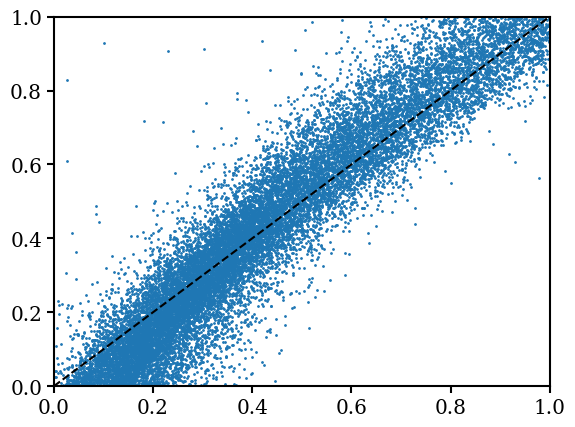

In [12]:
with torch.no_grad(): 
    _msurv_pred = best_model.forward(
        torch.tensor(__thetas_v.astype(np.float32)).to(device)).cpu().numpy()

plt.scatter(_msurvs_nmf_v, _msurv_pred, s=1)
plt.plot([0., 1.], [0., 1.], c='k', ls='--')
plt.xlim(0., 1)
plt.ylim(0., 1)

(-0.05, 0.05)

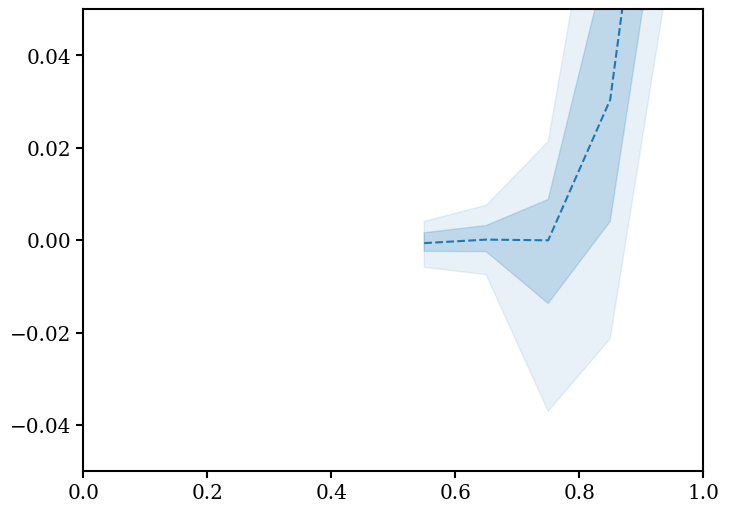

In [17]:
dmsurv = (msurv_nmf_v - (_msurv_pred[:,0] * msurv_nmf_scale + msurv_nmf_shift))

fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)

mm, qs = [], []
for i in range(10): 
    inbin = (msurv_nmf_v > 0.1*i) & (msurv_nmf_v < 0.1*(i+1))
    if np.sum(inbin) < 10: continue
    mm.append(0.1*(i+0.5))
    qs.append(np.quantile(dmsurv[inbin], (0.025, 0.16, 0.5, 0.84, 0.975)))
qs = np.array(qs)

sub.plot(mm, qs[:,2], c='C0', ls='--')
sub.fill_between(mm, qs[:,0], qs[:,4], color='C0', alpha=0.1)
sub.fill_between(mm, qs[:,1], qs[:,3], color='C0', alpha=0.2)

sub.set_xlim(0., 1.)
sub.set_ylim(-0.05, 0.05)

# 2. emulator for burst

In [35]:
# extract parameters relevant to NMF
__thetas = _thetas[:,5:]
__thetas_v = _thetas_v[:,5:]

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.from_numpy(__thetas[:Ntrain,:].astype(np.float32)),
    torch.from_numpy(_msurvs_burst[:Ntrain, None].astype(np.float32))), batch_size=512, shuffle=True)

valid_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.from_numpy(__thetas[Ntrain:,:].astype(np.float32)),
    torch.from_numpy(_msurvs_burst[Ntrain:, None].astype(np.float32))), batch_size=512, shuffle=True)

In [ ]:
########################################################
epochs = int(1e3)
patience = 20
n_hidden = 128
n_layers = 5
lrate = 1e-3

arch = [n_hidden for i in range(n_layers)]

mlp = flows.MLP(__thetas.shape[1], 1, n_hidden=arch, dropout=0.)
mlp.to(device)

optimizer = optim.Adam(mlp.parameters(), lr=lrate, weight_decay=0)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, lrate, epochs=epochs, steps_per_epoch=len(train_loader))

best_epoch = 0
best_valid_loss = np.inf
train_losses, valid_losses = [], []

for epoch in range(epochs):
    mlp.train()
    train_loss = 0
    for batch in train_loader:
        _x, _y = batch
        _x = _x.to(device)
        _y = _y.to(device)
        optimizer.zero_grad()

        loss = F.mse_loss(_y, mlp.forward(_x))#torch.mean(loss)
        loss.backward()
        train_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(mlp.parameters(), 1)
        optimizer.step()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    with torch.no_grad():
        valid_loss = 0
        for val_batch in valid_loader:
            x_val, y_val = val_batch
            x_val = x_val.to(device)
            y_val = y_val.to(device)

            _loss = F.mse_loss(y_val, mlp.forward(x_val))#torch.mean(_loss)
            valid_loss += _loss.item()
        valid_loss /= len(valid_loader)
        if np.isnan(valid_loss): raise ValueError
        valid_losses.append(valid_loss)

    scheduler.step()
    
    if epoch % 10 == 0: 
        print('Epoch: %i TRAINING Loss: %.2e VALIDATION Loss: %.2e' % (epoch, train_loss, valid_loss))

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        best_model = copy.deepcopy(mlp)

    else:
        if epoch > best_epoch + patience:
            print('Stopping')
            print('====> Epoch: %i TRAINING Loss: %.2e VALIDATION Loss: %.2e' % (epoch, train_loss, best_valid_loss))
            break

Epoch: 0 TRAINING Loss: 9.38e-01 VALIDATION Loss: 7.42e-01
Epoch: 10 TRAINING Loss: 6.83e-02 VALIDATION Loss: 6.38e-02
Epoch: 20 TRAINING Loss: 3.45e-02 VALIDATION Loss: 3.01e-02
Epoch: 30 TRAINING Loss: 1.66e-02 VALIDATION Loss: 1.39e-02
Epoch: 40 TRAINING Loss: 1.08e-02 VALIDATION Loss: 9.24e-03
Epoch: 50 TRAINING Loss: 8.06e-03 VALIDATION Loss: 7.11e-03
Epoch: 60 TRAINING Loss: 6.25e-03 VALIDATION Loss: 5.43e-03
Epoch: 70 TRAINING Loss: 5.47e-03 VALIDATION Loss: 4.72e-03


In [23]:
# if satisfactory save best model
torch.save(best_model, '/pscratch/sd/c/chahah/sedflow/msurv/modelb/emu_msurv.v2.burst.pt')

(0.0, 1.0)

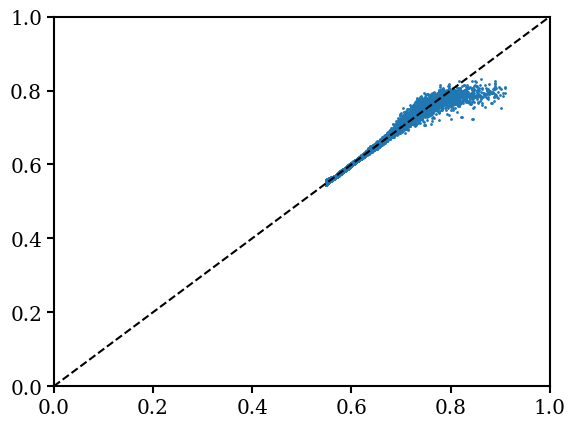

In [28]:
with torch.no_grad(): 
    _msurv_pred = best_model.forward(
        torch.tensor(__thetas_v.astype(np.float32)).to(device)).cpu().numpy()

plt.scatter(_msurvs_burst_v * msurv_burst_scale + msurv_burst_shift, _msurv_pred * msurv_burst_scale + msurv_burst_shift, s=1)
plt.plot([0., 1.], [0., 1.], c='k', ls='--')
plt.xlim(0., 1)
plt.ylim(0., 1)

(-0.05, 0.05)

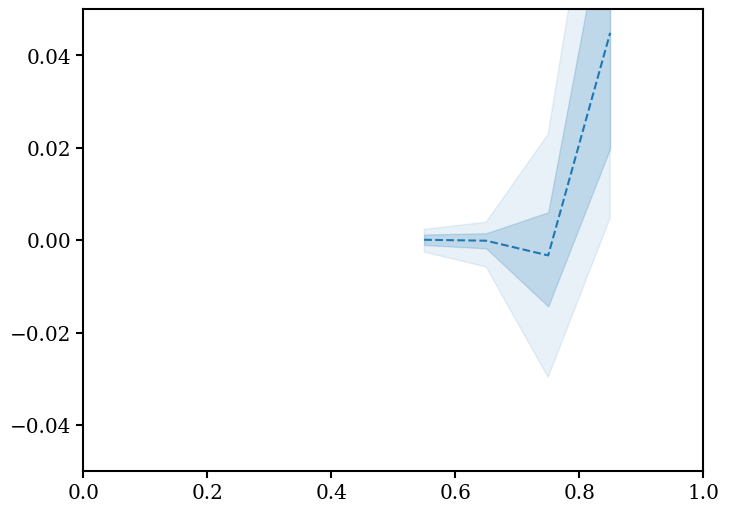

In [27]:
dmsurv = (msurv_burst_v - (_msurv_pred[:,0] * msurv_burst_scale + msurv_burst_shift))

fig = plt.figure(figsize=(8,6))
sub = fig.add_subplot(111)

mm, qs = [], []
for i in range(10): 
    inbin = (msurv_burst_v > 0.1*i) & (msurv_burst_v < 0.1*(i+1))
    if np.sum(inbin) < 10: continue 
    mm.append(0.1*(i+0.5))
    qs.append(np.quantile(dmsurv[inbin], (0.025, 0.16, 0.5, 0.84, 0.975)))
qs = np.array(qs)

sub.plot(mm, qs[:,2], c='C0', ls='--')
sub.fill_between(mm, qs[:,0], qs[:,4], color='C0', alpha=0.1)
sub.fill_between(mm, qs[:,1], qs[:,3], color='C0', alpha=0.2)

sub.set_xlim(0., 1.)
sub.set_ylim(-0.05, 0.05)

## load multiple sets of training data

In [7]:
dat_dir = os.path.join(U.data_dir(), 'seds', 'modelb') 

thetas, msurv = [], []
for i in np.random.choice(np.arange(10), size=3, replace=False): 
    sps     = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_unt.npz' % i))['arr_0'][:,1:8]
    sps[:,5] = np.log10(sps[:,5])
    sps[:,6] = np.log10(sps[:,6])
    tage    = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_t_age.npz.npy' % i))
    msurv.append(np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv.npz.npy' % i)))

    thetas.append(np.concatenate([sps, tage[:,None]], axis=1))
    
thetas = np.concatenate(thetas, axis=0)
msurv = np.concatenate(msurv, axis=0)

In [8]:
output_dir = '/pscratch/sd/c/chahah/sedflow/msurv/modelb/'
theta_shift = np.load(os.path.join(output_dir, 'thetas_shift.all.v1.npy'))
theta_scale = np.load(os.path.join(output_dir, 'thetas_scale.all.v1.npy'))

msurv_shift = np.load(os.path.join(output_dir, 'msurv_shift.all.v1.npy'))
msurv_scale = np.load(os.path.join(output_dir, 'msurv_scale.all.v1.npy'))

In [9]:
_thetas = (thetas - theta_shift) / theta_scale
_msurvs = (msurv - msurv_shift) / msurv_scale

In [10]:
torch.autograd.set_detect_anomaly(True)

Ntrain = int(0.9 * _thetas.shape[0])
Nvalid = _thetas.shape[0] - Ntrain
print('Ntrain = %i' % Ntrain)

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.from_numpy(_thetas[:Ntrain,:].astype(np.float32)),
    torch.from_numpy(_msurvs[:Ntrain].astype(np.float32))), batch_size=512, shuffle=True)

valid_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(
    torch.from_numpy(_thetas[Ntrain:,:].astype(np.float32)),
    torch.from_numpy(_msurvs[Ntrain:].astype(np.float32))), batch_size=512, shuffle=True)

Ntrain = 270000


In [11]:
epochs = int(1e4)
patience = 20
lrate = 1e-4

optimizer = optim.Adam(mlp.parameters(), lr=lrate, weight_decay=0)

#scheduler = optim.lr_scheduler.OneCycleLR(optimizer, lrate, epochs=epochs, steps_per_epoch=len(train_loader))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, threshold=0.0001)

In [12]:
best_epoch = 0
best_valid_loss = np.inf
train_losses, valid_losses = [], []

for epoch in range(epochs):
    mlp.train()
    train_loss = 0
    for batch in train_loader:
        _x, _y = batch
        _x = _x.to(device)
        _y = _y.to(device)
        optimizer.zero_grad()

        loss = F.mse_loss(_y, mlp.forward(_x))#torch.mean(loss)
        loss.backward()
        train_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(mlp.parameters(), 1)
        optimizer.step()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    with torch.no_grad():
        valid_loss = 0
        for val_batch in valid_loader:
            x_val, y_val = val_batch
            x_val = x_val.to(device)
            y_val = y_val.to(device)

            _loss = F.mse_loss(y_val, mlp.forward(x_val))#torch.mean(_loss)
            valid_loss += _loss.item()
        valid_loss /= len(valid_loader)
        if np.isnan(valid_loss): raise ValueError
        valid_losses.append(valid_loss)

    #scheduler.step()
    scheduler.step(valid_loss)

    print('Epoch: %i TRAINING Loss: %.2e VALIDATION Loss: %.2e LEARNING RATE: %.2e' % (epoch, train_loss, valid_loss, 
                                                                                       scheduler.get_last_lr()[-1]))

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        best_model = copy.deepcopy(mlp)

    else:
        if epoch > best_epoch + patience:
            print('Stopping')
            print('====> Epoch: %i TRAINING Loss: %.2e VALIDATION Loss: %.2e' % (epoch, train_loss, best_valid_loss))
            break

Epoch: 0 TRAINING Loss: 2.70e-03 VALIDATION Loss: 2.86e-03 LEARNING RATE: 1.00e-04
Epoch: 1 TRAINING Loss: 2.61e-03 VALIDATION Loss: 3.15e-03 LEARNING RATE: 1.00e-04
Epoch: 2 TRAINING Loss: 2.62e-03 VALIDATION Loss: 3.16e-03 LEARNING RATE: 1.00e-04
Epoch: 3 TRAINING Loss: 2.66e-03 VALIDATION Loss: 2.80e-03 LEARNING RATE: 1.00e-04
Epoch: 4 TRAINING Loss: 2.59e-03 VALIDATION Loss: 2.90e-03 LEARNING RATE: 1.00e-04
Epoch: 5 TRAINING Loss: 2.51e-03 VALIDATION Loss: 3.00e-03 LEARNING RATE: 1.00e-04
Epoch: 6 TRAINING Loss: 2.38e-03 VALIDATION Loss: 3.16e-03 LEARNING RATE: 1.00e-04
Epoch: 7 TRAINING Loss: 2.48e-03 VALIDATION Loss: 2.96e-03 LEARNING RATE: 1.00e-04
Epoch: 8 TRAINING Loss: 2.45e-03 VALIDATION Loss: 2.91e-03 LEARNING RATE: 1.00e-04
Epoch: 9 TRAINING Loss: 2.39e-03 VALIDATION Loss: 2.98e-03 LEARNING RATE: 1.00e-04
Epoch: 10 TRAINING Loss: 2.40e-03 VALIDATION Loss: 3.20e-03 LEARNING RATE: 1.00e-04
Epoch: 11 TRAINING Loss: 2.39e-03 VALIDATION Loss: 2.82e-03 LEARNING RATE: 1.00e-04
Ep

In [13]:
def test_model(mlp): 
    # load valid data
    i = 999
    dat_dir = '/pscratch/sd/c/chahah/sedflow/seds/modelb/'
    #sps = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_sps.npz' % i))['arr_0'][:,1:9]
    sps = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_unt.npz' % i))['arr_0'][:,1:8]
    tage = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_t_age.npz.npy' % i))
    msurv = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv.npz.npy' % i))

    #sps[:,6] = np.log10(sps[:,6])
    #sps[:,7] = np.log10(sps[:,7])
    sps[:,5] = np.log10(sps[:,5])
    sps[:,6] = np.log10(sps[:,6])

    thetas = np.concatenate([sps, tage[:,None]], axis=1)

    _thetas = (thetas - theta_shift) / theta_scale
    _msurvs = (msurv - msurv_shift) / msurv_scalea

    with torch.no_grad(): 
        _msurv_pred = mlp.forward(torch.tensor(_thetas.astype(np.float32)).to(device)).cpu().numpy()* msurv_scale + msurv_shift

    plt.scatter(_msurvs * msurv_scale + msurv_shift, _msurv_pred, s=1)
    plt.plot([0., 1.], [0., 1.], c='k', ls='--')
    plt.xlim(0., 1)
    plt.ylim(0., 1)
    plt.show()
    return None

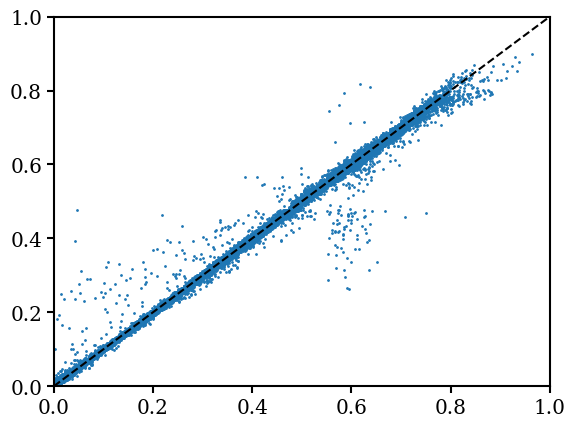

In [14]:
test_model(best_model)